# User Distribution by Category

C:\Users\SajayN\AppData\Local\Temp\ipykernel_53908\3185018647.py:40: SAWarning: Unrecognized server version info '17.0.1115.1'.  Some SQL Server features may not function properly.
  with engine.connect() as con:


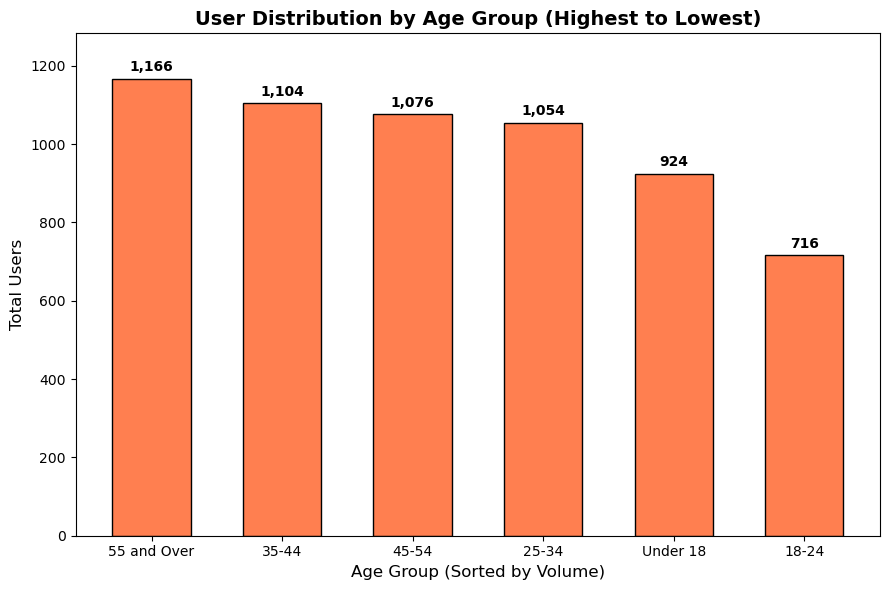

In [2]:
import pandas as pd
from sqlalchemy import create_engine
import matplotlib.pyplot as plt

# 1. Setup your database engine
connection_string = (
    "mssql+pyodbc://@./DA07_movieDB?"
    "driver=ODBC+Driver+17+for+SQL+Server&trusted_connection=yes"
)
engine = create_engine(connection_string)

# 2. SQL Query updated to sort by total_users DESC
query = """
SELECT 
    CASE 
        WHEN age < 18 THEN 'Under 18'
        WHEN age BETWEEN 18 AND 24 THEN '18-24'
        WHEN age BETWEEN 25 AND 34 THEN '25-34'
        WHEN age BETWEEN 35 AND 44 THEN '35-44'
        WHEN age BETWEEN 45 AND 54 THEN '45-54'
        ELSE '55 and Over'
    END AS age_group,
    COUNT(user_id) AS total_users
FROM [dbo].[users]
GROUP BY 
    CASE 
        WHEN age < 18 THEN 'Under 18'
        WHEN age BETWEEN 18 AND 24 THEN '18-24'
        WHEN age BETWEEN 25 AND 34 THEN '25-34'
        WHEN age BETWEEN 35 AND 44 THEN '35-44'
        WHEN age BETWEEN 45 AND 54 THEN '45-54'
        ELSE '55 and Over'
    END
ORDER BY 
    total_users DESC; -- This puts the highest user count first
"""

try:
    # 3. Pull the query output into your data frame
    with engine.connect() as con:
        df_age_groups = pd.read_sql(query, con)
    
    # 4. Initialize the plot window
    plt.figure(figsize=(9, 6))
    
    # 5. Build the vertical bar chart (now sorted largest to smallest)
    bars = plt.bar(
        df_age_groups['age_group'], 
        df_age_groups['total_users'], 
        color='coral', 
        edgecolor='black',
        width=0.6
    )
    
    # 6. Inject the exact user count numbers on top of each bar
    for bar in bars:
        height = bar.get_height()
        plt.text(
            bar.get_x() + bar.get_width()/2, 
            height + (max(df_age_groups['total_users']) * 0.01), 
            f'{int(height):,}', 
            va='bottom', 
            ha='center', 
            fontweight='bold',
            fontsize=10
        )
    
    # 7. Customize the chart layout
    plt.xlabel('Age Group (Sorted by Volume)', fontsize=12)
    plt.ylabel('Total Users', fontsize=12)
    plt.title('User Distribution by Age Group (Highest to Lowest)', fontsize=14, fontweight='bold')
    
    # Add whitespace padding to the top of the y-axis
    plt.ylim(0, max(df_age_groups['total_users']) * 1.1)
    
    plt.tight_layout()
    plt.show()

except Exception as e:
    print(f"An error occurred: {e}")

# Using Seaborn

C:\Users\SajayN\AppData\Local\Temp\ipykernel_20380\2105254961.py:51: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql(query, con)


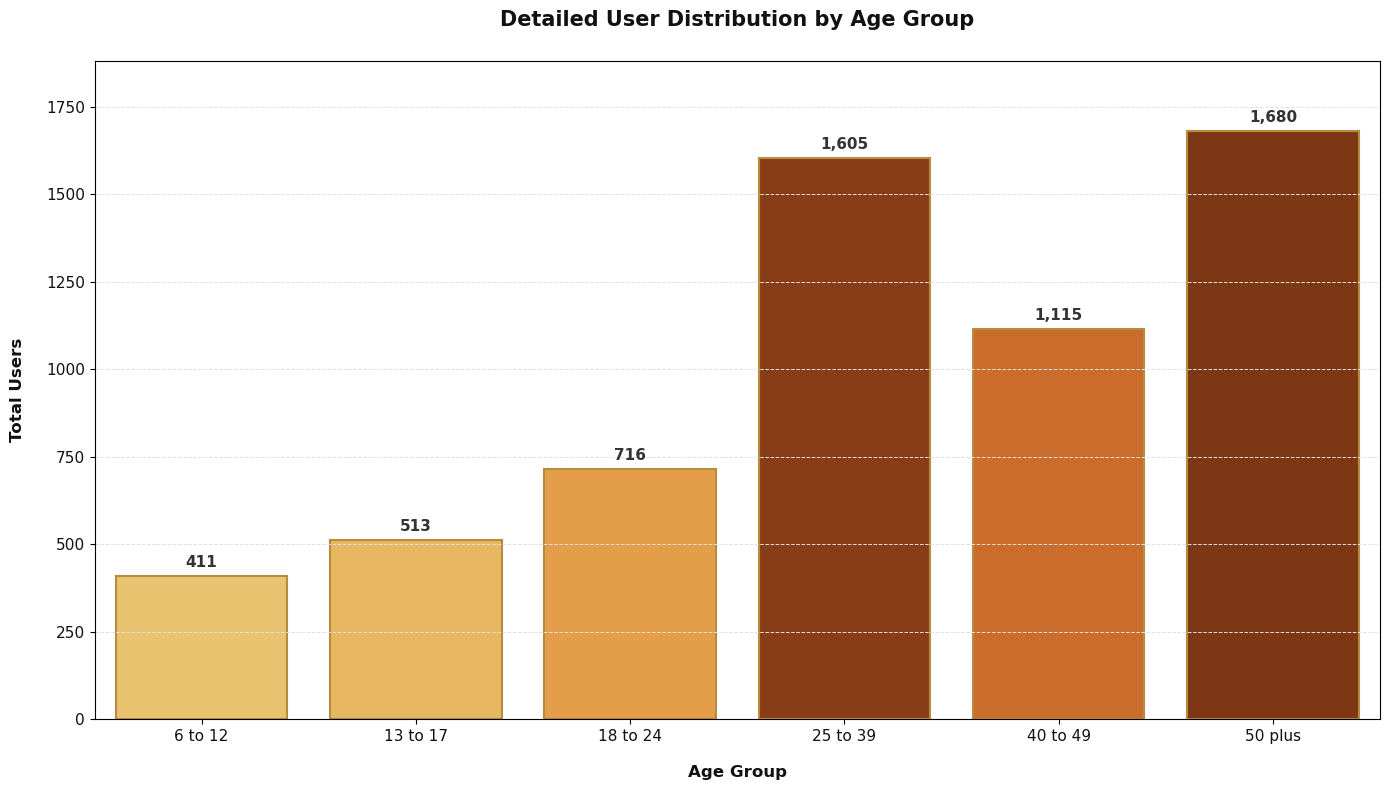

In [5]:
import pyodbc
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib import cm
import matplotlib.colors as mcolors

# 1. Connect to your SQL Server
con = pyodbc.connect(
    DRIVER='{ODBC Driver 17 for SQL Server}', 
    SERVER='.', 
    DATABASE='DA07_movieDB', 
    Trusted_Connection='Yes', 
    autocommit=True
)

# 2. SQL Query: Categorizes individual user ages into your targeted age groups
query = """
SELECT 
    AgeGroup,
    COUNT(user_id) AS total_users
FROM (
    SELECT 
        user_id,
        CASE 
            WHEN age BETWEEN 0 AND 5   THEN '0 to 5'
            WHEN age BETWEEN 6 AND 12  THEN '6 to 12'
            WHEN age BETWEEN 13 AND 17 THEN '13 to 17'
            WHEN age BETWEEN 18 AND 24 THEN '18 to 24'
            WHEN age BETWEEN 25 AND 39 THEN '25 to 39'
            WHEN age BETWEEN 40 AND 49 THEN '40 to 49'
            WHEN age >= 50             THEN '50 plus'
            ELSE 'Unknown'
        END AS AgeGroup
    FROM [dbo].[Users]
) AS CategorizedUsers
WHERE AgeGroup <> 'Unknown'
GROUP BY AgeGroup
ORDER BY 
    CASE AgeGroup
        WHEN '0 to 5'   THEN 1
        WHEN '6 to 12'  THEN 2
        WHEN '13 to 17' THEN 3
        WHEN '18 to 24' THEN 4
        WHEN '25 to 39' THEN 5
        WHEN '40 to 49' THEN 6
        WHEN '50 plus'  THEN 7
    END;
"""

df = pd.read_sql(query, con)
con.close()

# 3. Create a dynamic gradient mapping based on the value of total_users
# This ensures the highest value gets the boldest color and the lowest gets the lightest.
if not df.empty:
    min_users = df['total_users'].min()
    max_users = df['total_users'].max()
    
    if max_users == min_users:
        norm_vals = [0.6] * len(df)
    else:
        # Normalize between 0.35 and 0.90 to get a rich metallic gold/orange without being too pale or dark
        norm_vals = 0.35 + 0.55 * (df['total_users'] - min_users) / (max_users - min_users)
    
    # Use the YlOrBr colormap for a beautiful metallic/amber transition
    colormap = cm.YlOrBr
    bar_colors = [mcolors.to_hex(colormap(val)) for val in norm_vals]
else:
    bar_colors = []

# 4. Setup the Interface Canvas with a White Background
plt.figure(figsize=(14, 8), facecolor='#FFFFFF') 
ax = plt.gca()
ax.set_facecolor('#FFFFFF')

# Create the VERTICAL bar plot using our metallic gradient color list
sns.barplot(
    x='AgeGroup', 
    y='total_users', 
    data=df, 
    palette=bar_colors,
    hue='AgeGroup',
    legend=False,
    edgecolor='#B68D40',  # Complimentary bronze/gold border to emphasize the metal finish
    linewidth=1.5
)

# 5. Styling with your requested Title
plt.title('Detailed User Distribution by Age Group', 
          fontsize=15, fontweight='bold', color='#111111', pad=25)

plt.xlabel('Age Group', fontsize=12, fontweight='bold', color='#111111', labelpad=15)
plt.ylabel('Total Users', fontsize=12, fontweight='bold', color='#111111', labelpad=15)

# Style tick marks
plt.xticks(color='#111111', fontsize=11)
plt.yticks(color='#111111', fontsize=11)
plt.grid(color='#E0E0E0', linestyle='--', linewidth=0.7, axis='y') 

# Dynamically adjust Y-axis ceiling limit to give breathing room for the text labels on top
if not df.empty:
    plt.ylim(0, df['total_users'].max() * 1.12) 

# 6. Clean Vertical Bar Data Labels
for i, p in enumerate(ax.patches):
    height = p.get_height()
    user_count = int(df.iloc[i]['total_users'])
    
    label_text = f"{user_count:,}"
    
    ax.text(
        p.get_x() + p.get_width() / 2, 
        height + (df['total_users'].max() * 0.01), 
        label_text, 
        ha='center', 
        va='bottom', 
        fontsize=11, 
        fontweight='bold',
        color='#333333'
    )

# Optimize layout constraints
plt.tight_layout()
plt.show()